# \[Kaggle\] Urinary biomarkers for pancreatic cancer

SEOYEON CHOI  
2025-09-30

# data

[link](https://www.kaggle.com/datasets/johnjdavisiv/urinary-biomarkers-for-pancreatic-cancer/data)

| Column name             | Original column name                    | Details                                                                                                                                                                      |
|------------------------------|--------------------------------|-----------|
| sample_id               | Sample ID                               | Unique string identifying each subject                                                                                                                                       |
| patient_cohort          | Patient’s Cohort                        | Cohort 1: previously used samples; Cohort 2: newly added samples                                                                                                             |
| sample_origin           | Sample Origin                           | BPTB: Barts Pancreas Tissue Bank, London, UK; ESP: Spanish National Cancer Research Centre, Madrid, Spain; LIV: Liverpool University, UK; UCL: University College London, UK |
| age                     | Age                                     | Age in years                                                                                                                                                                 |
| sex                     | Sex                                     | M = male, F = female                                                                                                                                                         |
| diagnosis               | Diagnosis (1=Control, 2=Benign, 3=PDAC) | 1 = control (no pancreatic disease), 2 = benign hepatobiliary disease (119 of which are chronic pancreatitis), 3 = Pancreatic ductal adenocarcinoma (pancreatic cancer)      |
| stage                   | Stage                                   | For those with pancreatic cancer, one of IA, IB, IIA, IIIB, III, IV                                                                                                          |
| benign_sample_diagnosis | Benign Samples Diagnosis                | For those with a benign, non-cancerous diagnosis, what was the diagnosis?                                                                                                    |
| plasma_CA19_9           | Plasma CA19-9 U/ml                      | Blood plasma levels of CA 19–9, often elevated in pancreatic cancer. Only assessed in 350 patients.                                                                          |
| creatinine              | Creatinine mg/ml                        | Urinary biomarker of kidney function                                                                                                                                         |
| LYVE1                   | LYVE1 ng/ml                             | Urinary levels of Lymphatic vessel endothelial hyaluronan receptor 1, may play a role in tumor metastasis                                                                    |
| REG1B                   | REG1B ng/ml                             | Urinary levels of a protein that may be associated with pancreas regeneration                                                                                                |
| TFF1                    | TFF1 ng/ml                              | Urinary levels of Trefoil Factor 1, related to regeneration and repair of urinary tract                                                                                      |
| REG1A                   | REG1A ng/ml                             | Urinary levels of a protein associated with pancreas regeneration. Only assessed in 306 patients.                                                                            |

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# 통계 검정
from scipy.stats import f_oneway
# ml
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report


# Data

In [12]:
df = pd.read_csv('../../../delete/Debernardi et al 2020 data.csv')

In [13]:
df

590 rows × 14 columns

In [6]:
df.describe()

In [9]:
for col in df.select_dtypes(include=['object', 'category']).columns:
    print(f"\n📊 {col}")
    print(df[col].value_counts(dropna=False))


📊 sample_id
S1      1
S588    1
S302    1
S288    1
S497    1
       ..
S282    1
S321    1
S323    1
S363    1
S590    1
Name: sample_id, Length: 590, dtype: int64

📊 patient_cohort
Cohort1    332
Cohort2    258
Name: patient_cohort, dtype: int64

📊 sample_origin
BPTB    409
LIV     132
ESP      29
UCL      20
Name: sample_origin, dtype: int64

📊 sex
F    299
M    291
Name: sex, dtype: int64

📊 stage
NaN    391
III     76
IIB     68
IV      21
IB      12
IIA     11
II       7
IA       3
I        1
Name: stage, dtype: int64

📊 benign_sample_diagnosis
NaN                                                             382
Pancreatitis                                                     41
Pancreatitis (Chronic)                                           35
Gallstones                                                       21
Pancreatitis (Alcohol-Chronic)                                   11
Cholecystitis                                                     9
Serous cystadenoma - NOS          

## diagnosis level visualization by Biomarker

In [16]:
df['diagnosis_label'] = df['diagnosis'].map({1:'Control', 2:'Benign', 3:'PDAC'})

In [17]:
biomarkers = ['LYVE1', 'REG1B', 'TFF1', 'REG1A', 'plasma_CA19_9', 'creatinine']

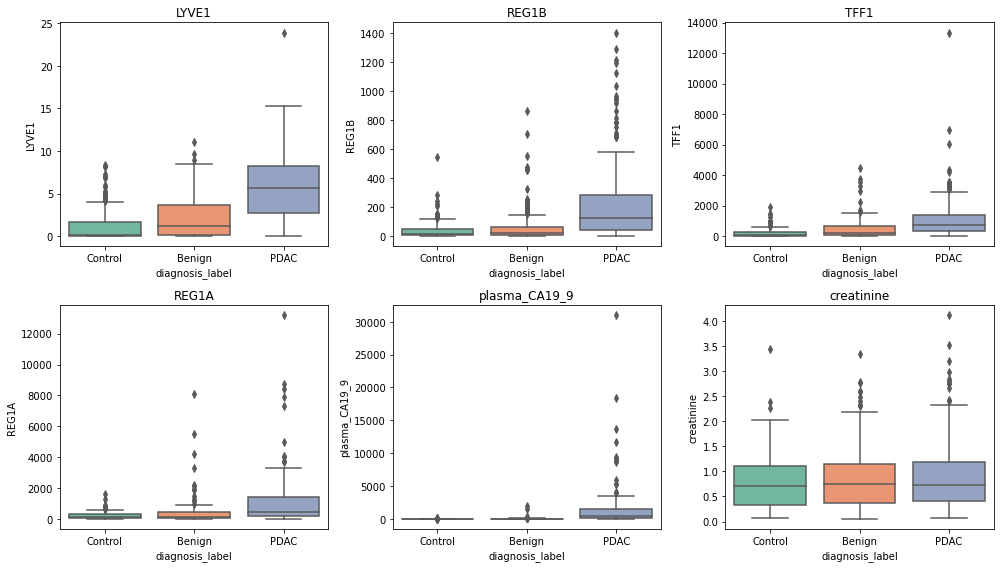

In [22]:
plt.figure(figsize=(14, 8))
for i, biomarker in enumerate(biomarkers, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df, x='diagnosis_label', y=biomarker, palette='Set2')
    plt.title(biomarker)
    plt.tight_layout()
plt.show()

-   췌장암 환자 PDAC
    -   LYVE1이 높음. REG1B가 높음 TFF1이 높음, REF1A가 높음

## Statistical Test

In [25]:
for biomarker in biomarkers:
    groups = [df[df['diagnosis_label'] == g][biomarker].dropna() for g in df['diagnosis_label'].unique()]
    stat, p = f_oneway(*groups)
    print(f"{biomarker}: p-value = {p:.4f}")

LYVE1: p-value = 0.0000
REG1B: p-value = 0.0000
TFF1: p-value = 0.0000
REG1A: p-value = 0.0000
plasma_CA19_9: p-value = 0.0000
creatinine: p-value = 0.1894

-   dignose level 별로 그룹 간 차이가 있는지
    -   creatime 빼고 다 차이 있음

## Prediction

-   target, features

In [28]:
X = df[biomarkers].fillna(0)
y = df['diagnosis']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

-   randomforest

In [30]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42) In a Jupyter environment, please rerun this cell to show the HTML representation or trust the notebook. On GitHub, the HTML representation is unable to render, please try loading this page with nbviewer.org. RandomForestClassifier RandomForestClassifier(random_state=42)

-   prediction

In [31]:
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.76      0.76      0.76        41
           2       0.61      0.59      0.60        39
           3       0.85      0.87      0.86        38

    accuracy                           0.74       118
   macro avg       0.74      0.74      0.74       118
weighted avg       0.74      0.74      0.74       118


## Check Feature Importance

In [35]:
importances = pd.Series(rf.feature_importances_, index=biomarkers).sort_values(ascending=False)
importances

plasma_CA19_9    0.241888
LYVE1            0.216604
TFF1             0.181022
REG1B            0.146198
creatinine       0.123882
REG1A            0.090405
dtype: float64

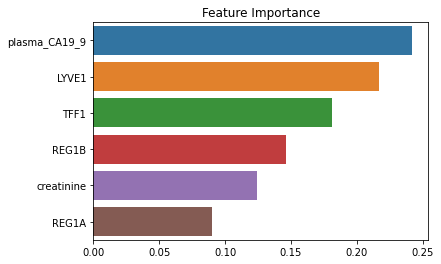

In [36]:
sns.barplot(x=importances, y=importances.index)
plt.title('Feature Importance')
plt.show()